<a href="https://colab.research.google.com/github/GyangShady/GAN_Image_Generator/blob/main/GAN_Image_Generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

using device cuda
Epoch [1/10] | D Loss: 0.2737 | G Loss: 3.2767
Epoch [2/10] | D Loss: 0.1759 | G Loss: 4.3220


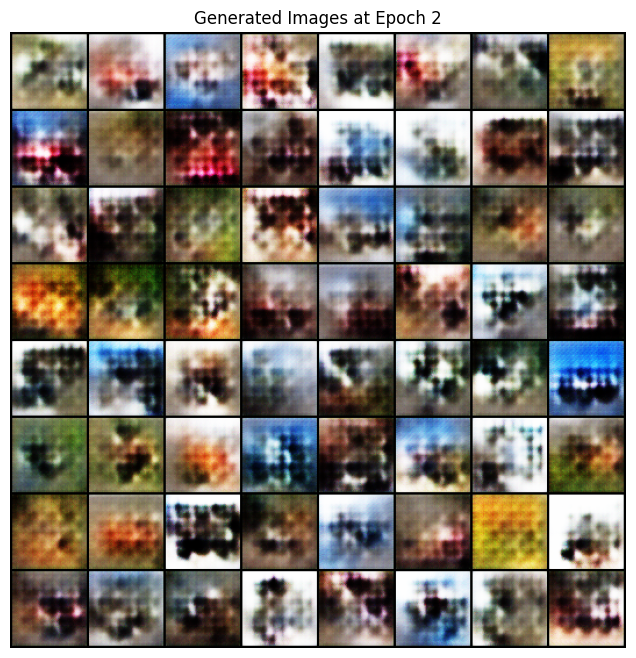

Epoch [3/10] | D Loss: 0.2533 | G Loss: 3.5310
Epoch [4/10] | D Loss: 0.4290 | G Loss: 5.3201


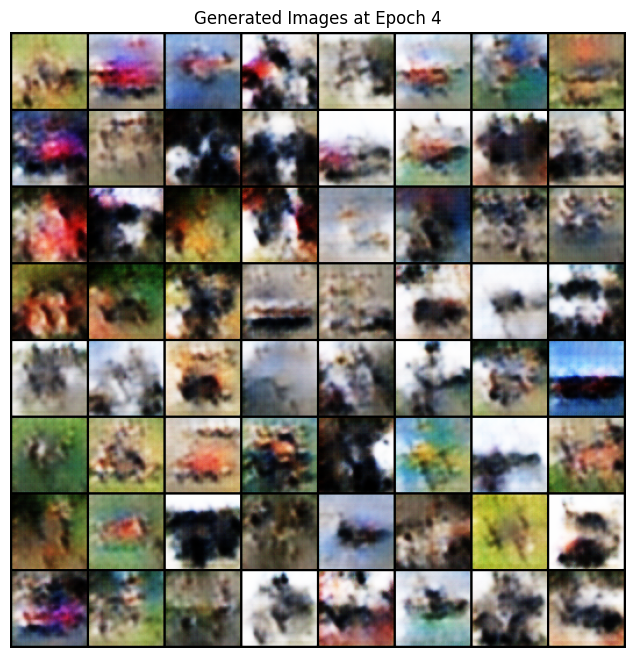

Epoch [5/10] | D Loss: 0.5400 | G Loss: 1.7727
Epoch [6/10] | D Loss: 0.0211 | G Loss: 3.6989


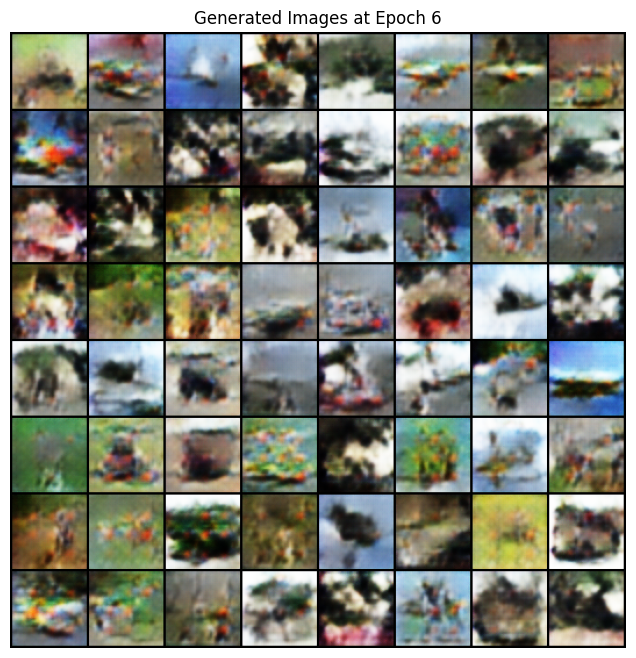

Epoch [7/10] | D Loss: 0.0170 | G Loss: 8.0395
Epoch [8/10] | D Loss: 0.0039 | G Loss: 7.6449


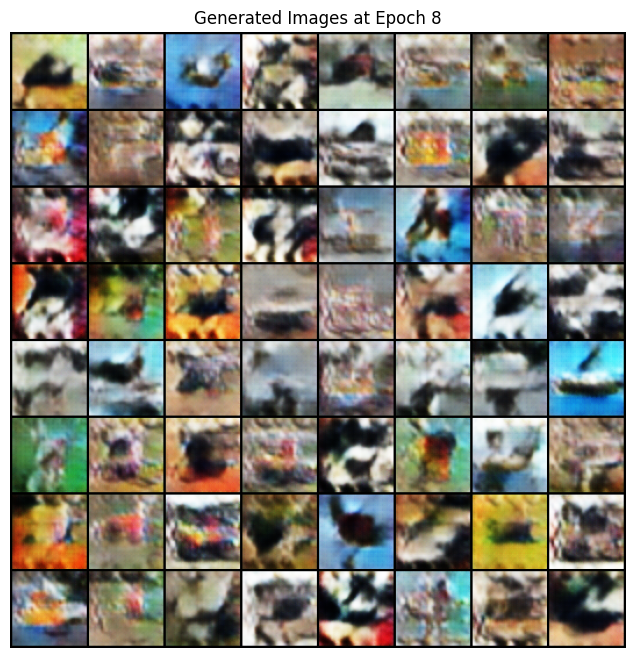

Epoch [9/10] | D Loss: 0.1441 | G Loss: 5.7902
Epoch [10/10] | D Loss: 0.0088 | G Loss: 9.2383


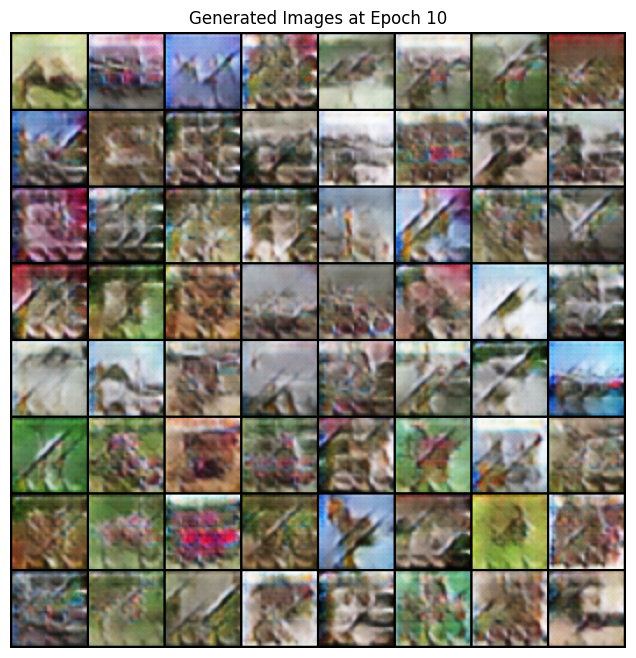

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision # Added explicit import for torchvision
from torchvision import datasets, transforms
from torchvision.utils import save_image
import matplotlib.pyplot as plt
import numpy as np

# Use GPU if available
device = torch.device("cuda" if
torch.cuda.is_available() else "cpu")
print("using device", device)

# Download CIFAR-10 dataset
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


dataset = datasets.CIFAR10(root='data',
download=True, transform=transform)
loader = torch.utils.data.DataLoader(dataset,
batch_size=128, shuffle=True)

# --- Generator ---
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(100, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
               nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

# --- Discriminator ---
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
 nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.model(img).view(-1, 1).squeeze(1)

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

epochs = 10  # You can increase to 50 for better results
fixed_noise = torch.randn(64, 100, 1, 1, device=device)


for epoch in range(epochs):
    for i, (imgs, _) in enumerate(loader):
        real_imgs = imgs.to(device)
        real_labels = torch.ones(imgs.size(0), device=device)
        fake_labels = torch.zeros(imgs.size(0), device=device)
         # Train Discriminator
        z = torch.randn(imgs.size(0), 100, 1, 1, device=device)
        fake_imgs = G(z)
        D_real = D(real_imgs)
        D_fake = D(fake_imgs.detach())
        loss_D = (criterion(D_real, real_labels) + criterion(D_fake, fake_labels)) / 2
        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train Generator
        D_fake = D(fake_imgs)
        loss_G = criterion(D_fake, real_labels)
        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()
    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

    # Save samples
    save_image(fake_imgs[:25], f"generated_epoch_{epoch+1}.png", nrow=5, normalize=True)

    if (epoch+1) % 2 == 0:
        with torch.no_grad():
            fake = G(fixed_noise).detach().cpu()
        grid = torchvision.utils.make_grid(fake, padding=2, normalize=True)
        plt.figure(figsize=(8,8))
        plt.axis("off")
        plt.title(f"Generated Images at Epoch {epoch+1}")
        plt.imshow(np.transpose(grid, (1,2,0)))
        plt.show()

In [ ]:
!pip install torch torchvision matplotlib